# Working with and visualizing 4 dimensional datasets

Often times, oceanography datasets are 4-dimensional with latitude, longitude, depth, and time dimensions. 

In this workbook, we will walk through a couple types of figures oceanographers commonly use to visualize multi-dimensional datasets. 
For these examples we will use [SalishSeaCast](https://salishsea.eos.ubc.ca/nemo/) model data. This data source provides clean, consistently binned 4D data which will be useful for this example, but think about how visualizations may change when working with data that has non-uniform data bins, gaps, etc. 

In [7]:
# import data packages cell  

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display, Image
import urllib.parse
import time
import requests
import io
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import xarray
import urllib3

# fetch_griddap uses verify=False (ERDDAP server's cert isn't trusted in this environment);
# suppress the resulting per-request warning rather than at every call site
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

## A tiny bit of background behind Salish Sea Cast 

SalishSeaCast is a regional biogeochemical model built on NEMO architechture developed at the University of British Columbia led by Susan Allen. The Salish Sea is a marginal sea between Vancouver Island and the Southern BC mainland. Water enters the semi-enclosed basin of the Salish Sea through the Strait of Juan de Fuca in the south and the Johnstone Strait in the north. The model domain covers a rotated rectangular prisim. The rectangle consists of a 398 x 898 grid space and 40 depth levels. Each grid cell covers a 500m x 500m space. 

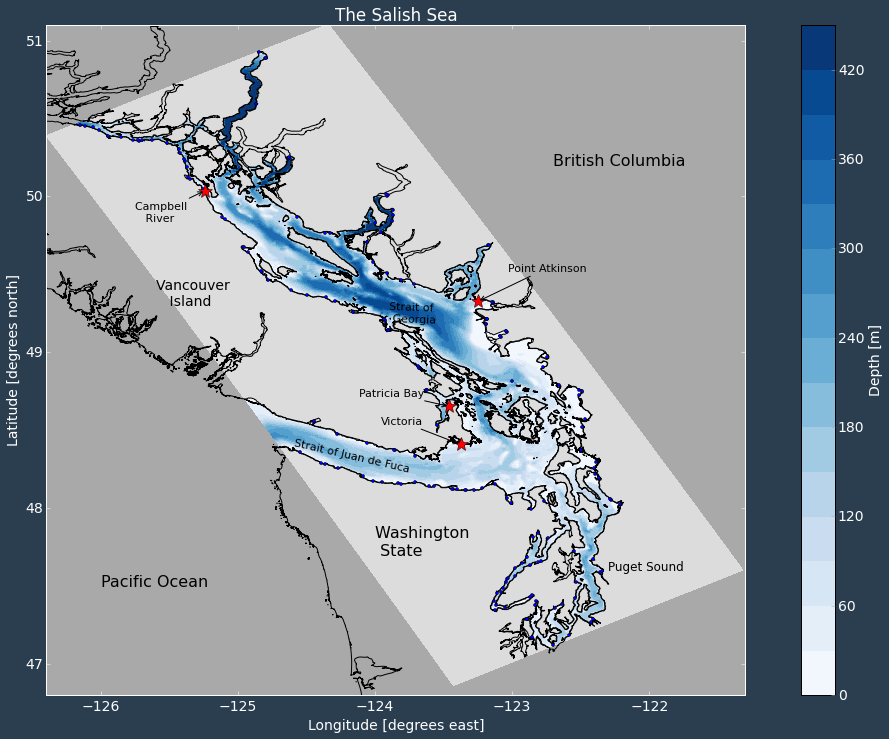!

### Project Resources
The main project documentation site is at [https://salishsea-meopar-docs.readthedocs.io/en/latest/].
The project team maintains a set of Git version control repositories for code, documentation (including the source files for this site), and analyses of model results. The contents of those repositories and their development history is accessible at [https://github.com/SalishSeaCast].

### Accessing the data behind the plots

`SalishSeaCast` data is accessible via ERDDAP in `griddap` format. This allows you to subset very large datafiles into more manageable chunks. In the cell below we will create a function that will build ERDDAP urls for us so we can pull just the data we need to create each plot. 

You will find datasets are segregated by temporal resolution (hourly or monthly) and according to model fields (Physics, Chemistry, Biology, Light Fields). Use the table below to determine which terms you should plug into the ERDDAP url builder function 

| Parameter | Temporal Resolution | dataset_id |
| --- | --- | --- |
| temperature | monthly | ubcSSg3DPhysicsFields1moV21-11 | 
| | hourly | ubcSSg3DPhysicsFields1hV21-11 | 
| salinity | monthly | ubcSSg3DPhysicsFields1moV21-11 |
| | hourly | ubcSSg3DPhysicsFields1hV21-11 |
| sigma_theta | monthly | ubcSSg3DPhysicsFields1moV21-11 |
| | hourly | ubcSSg3DPhysicsFields1hV21-11 |
| total_alkalinity | monthly | ubcSSg3DChemistryFields1moV21-11 | 
| | hourly | ubcSSg3DChemistryFields1hV21-11 | 
| dissolved_inorganic_carbon | monthly | ubcSSg3DChemistryFields1moV21-11 |
| | hourly | ubcSSg3DChemistryFields1hV21-11 |
| dissolved_oxygen | monthly | ubcSSg3DChemistryFields1moV21-11 |
| | hourly | ubcSSg3DChemistryFields1hV21-11 |
| flagellates | monthly | ubcSSg3DBiologyFields1moV21-11 | 
| | hourly | ubcSSg3DBiologyFields1hV21-11 | 
| diatoms | monthly | ubcSSg3DBiologyFields1moV21-11 |
| | hourly | ubcSSg3DBiologyFields1hV21-11 |
| z1_zooplankton | monthly | ubcSSg3DBiologyFields1moV21-11 | 
| | hourly |  ubcSSg3DBiologyFields1hV21-11 |
| z2_zooplankton | monthly | ubcSSg3DBiologyFields1moV21-11 |
| | hourly | ubcSSg3DBiologyFields1hV21-11 |
| silicon | monthly | ubcSSg3DBiologyFields1moV21-11 |
| | hourly | ubcSSg3DBiologyFields1hV21-11 | 
| biogenic_silicon| monthly | ubcSSg3DBiologyFields1moV21-11 | 
| | hourly | ubcSSg3DBiologyFields1hV21-11 | 
| ammonium | monthly | ubcSSg3DBiologyFields1moV21-11 | 
| | hourly | ubcSSg3DBiologyFields1hV21-11 |
| particulate_organic_nitrogen | monthly | ubcSSg3DBiologyFields1moV21-11 |
| | hourly | ubcSSg3DBiologyFields1hV21-11 | 
| dissolved_organic_nitrogen | monthly | ubcSSg3DBiologyFields1moV21-11 |
| | hourly | ubcSSg3DBiologyFields1hV21-11 |
| nitrate | monthly | ubcSSg3DBiologyFields1moV21-11 | 
| | hourly | ubcSSg3DBiologyFields1hV21-11 | 
| PAR | monthly | ubcSSg3DLightFields1moV21-11 | 
| | hourly | ubcSSg3DLightFields1hV21-11 | 
| turbidity | monthly | ubcSSg3DLightFields1moV21-11 | 
| | hourly | ubcSSg3DLightFields1hV21-11 | 

In [8]:
# ERDDAP builder function -- 
# Reusable helpers for building and fetching SalishSeaCast griddap data

SalishSeaERDDAP = 'https://salishsea.eos.ubc.ca/erddap/griddap/'
filetype = '.nc'

# Full model domain (see background section above): 40 depth levels, 898 x 398 horizontal grid
FULL_DEPTH = (0.5000003, 1, 441.4661)
FULL_GRIDY = (0, 1, 897.0)
FULL_GRIDX = (0.0, 1, 397.0)

# NOTE! If you are combining parameters of interest from the same dataset_id (e.g. temperature + salinity)
# you can pass them together as one `variables` list to get one url for all the data you want.
# If you are combining data from two or more different dataset_ids, you need to call
# build_griddap_url separately for each dataset_id (e.g. zooplankton + temperature)

def build_griddap_url(dataset_id, variables, time_range, depth_range=FULL_DEPTH,
                       gridY_range=FULL_GRIDY, gridX_range=FULL_GRIDX):
    """
    variables: list of variable names to request
    time_range, depth_range, gridY_range, gridX_range: each a (start, stride, end) tuple.
      Use 'last' as an end value to mean "most recent available".
    Keep each request's ranges as narrow as the plot actually needs -- the
    full domain across many months and variables is several GB and will not fit in memory.
    """
    def fmt(rng):
        start, stride, end = rng
        return f"[({start}):{stride}:({end})]"

    subset = fmt(time_range) + fmt(depth_range) + fmt(gridY_range) + fmt(gridX_range)
    query = ','.join(f"{v}{subset}" for v in variables)
    return f"{SalishSeaERDDAP}{dataset_id}{filetype}?{query}"


def fetch_griddap(url):
    """Download a griddap URL and return it as an xarray.Dataset."""
    response = requests.get(url, verify=False)
    response.raise_for_status()
    return xarray.open_dataset(io.BytesIO(response.content))

## Converting from rotated x, y grid to lon, lat 

SalishSeaCast projects onto a rotated x, y grid space. To put values in a geographical context, we need to convert from the x,y grid space to lon, lat. We will create a separate function for this. 

In [9]:
# Get the grid data - available as a file in the github repo
grid = xarray.open_dataset('ubcSSnBathymetryV21-08_a29d_efc9_4047.nc')
latitude = grid.latitude.values
longitude = grid.longitude.values
depth = grid.bathymetry.values

In [10]:
def latlon2salishgrid(lat_input, lon_input, latitude, longitude):
    """
    Convert latitude/longitude point(s) to the nearest SalishSeaCast grid indices.

    lat_input, lon_input: scalar or 1D array of the same length
    latitude, longitude: 2D grids (gridY, gridX) from the bathymetry dataset
        (e.g. from get_salish_grid())

    Returns (x, y): gridX, gridY index of the nearest grid cell (same shape as input)
    """
    latitude = np.asarray(latitude)
    longitude = np.asarray(longitude)
    lat_input = np.atleast_1d(lat_input)
    lon_input = np.atleast_1d(lon_input)

    x = np.empty(lat_input.shape, dtype=int)
    y = np.empty(lat_input.shape, dtype=int)

    for i, (la, lo) in enumerate(zip(lat_input, lon_input)):
        dist = np.hypot(latitude - la, longitude - lo)
        y[i], x[i] = np.unravel_index(np.argmin(dist), dist.shape)

    return (x[0], y[0]) if x.size == 1 else (x, y)

## Hovmöller Plots: Combining depth and time dimensions



In [11]:
# First, let's select a point within the model domain

lat_input = 49.247847  # Replace with your own lat lon coordinates 
lon_input = -123.501925

[x,y] = latlon2salishgrid(lat_input, lon_input,latitude,longitude)

# Use our build_ERDDAP_url and fetch_griddap functions to grab a year long time series at this single point location

yearsPrior = 10
stride = 1  # requested data interval
startTime = (pd.Timestamp.now(tz="UTC") - pd.DateOffset(years=yearsPrior)).strftime("%Y-%m-%dT%H:%M:%S.000Z")
hovmoller_url = build_griddap_url(    
    dataset_id='ubcSSg3DPhysicsFields1moV21-11', # replace with correct dataset_id from the table above
    variables=['temperature'],                   # replace with variable of interest
    time_range=(startTime, stride, 'last'),
    depth_range=FULL_DEPTH,                  # Full water column
    gridY_range=(y, 1, y),               # single grid cell
    gridX_range=(x, 1, x),
)
print(hovmoller_url)
data = fetch_griddap(hovmoller_url)
data

https://salishsea.eos.ubc.ca/erddap/griddap/ubcSSg3DPhysicsFields1moV21-11.nc?temperature[(2016-08-25T20:30:20.000Z):1:(last)][(0.5000003):1:(441.4661)][(469):1:(469)][(281):1:(281)]


<xarray.Dataset> Size: 20kB
Dimensions:      (time: 120, depth: 40, gridY: 1, gridX: 1)
Coordinates:
  * time         (time) datetime64[ns] 960B 2016-08-15T12:00:00 ... 2026-07-1...
  * depth        (depth) float32 160B 0.5 1.5 2.5 3.5 ... 387.6 414.5 441.5
  * gridY        (gridY) float64 8B 469.0
  * gridX        (gridX) float64 8B 281.0
Data variables:
    temperature  (time, depth, gridY, gridX) float32 19kB ...
Attributes: (12/26)
    acknowledgement:               MEOPAR, Ocean Networks Canada (ONC), Digit...
    cdm_data_type:                 Grid
    comment:                       If you use this dataset in your research,\...
    Conventions:                   CF-1.6, COARDS, ACDD-1.3
    creator_email:                 sallen@eoas.ubc.ca
    creator_name:                  SalishSeaCast Project Contributors
    ...                            ...
    standard_name_vocabulary:      CF Standard Name Table v91
    summary:                       Green, Salish Sea, 3d Physics Fields, Mont...
    testOutOfDate:                 now-36days
    time_coverage_end:             2026-07-15T12:00:00Z
    time_coverage_start:           2016-08-15T12:00:00Z
    title:                         Green, Salish Sea, 3d Physics Fields, Mont...

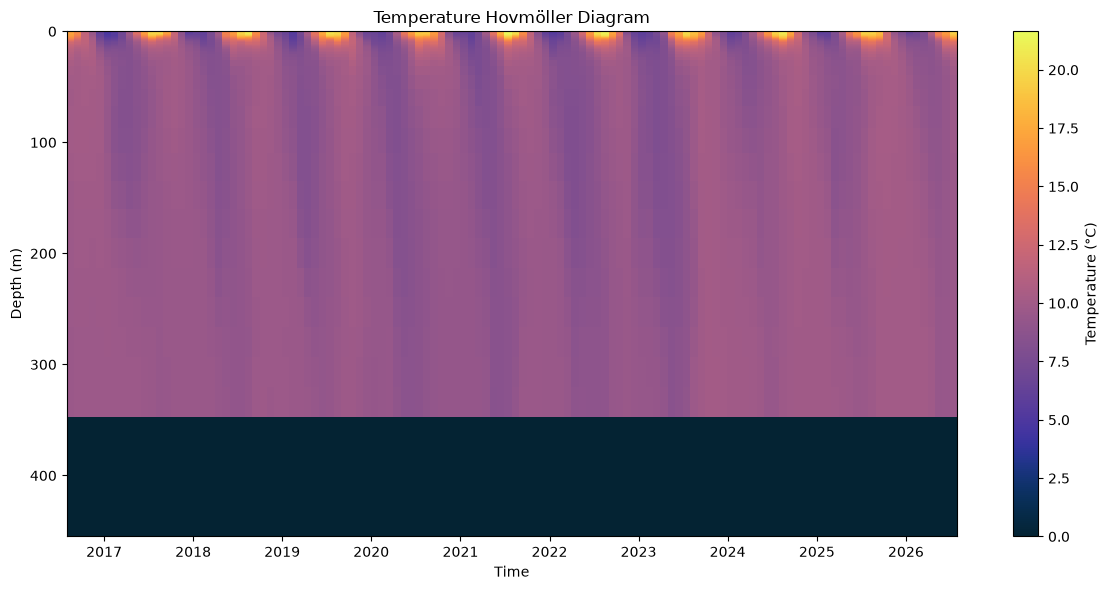

In [12]:
# Create plot

cData = data["temperature"].squeeze() # Replace with your variable of interest

plt.figure(figsize=(12, 6))

plt.pcolormesh(
    data["time"],
    data["depth"],
    cData.T, 
    shading="auto",
    cmap=cmocean.cm.thermal
)

plt.colorbar(label="Temperature (°C)")
plt.xlabel("Time")
plt.ylabel("Depth (m)")
plt.title("Temperature Hovmöller Diagram")

# Reverse y-axis so it appears surface - bottom
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Curtain plots: Combining depth and 1D horizontal space (e.g. latitude, longitude, or distance along transect, etc) 

Plot your variable of interest along the `thalweg` line through the Salish Sea 
A `thalweg` describes the deepest line through a valley or a basin through which a stream or ocean currents will flow fastest

/tmp/ipykernel_1844/2205440126.py:76: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = axes[0].pcolormesh(longitude, latitude, depth, shading="auto", cmap=cmocean.cm.deep)


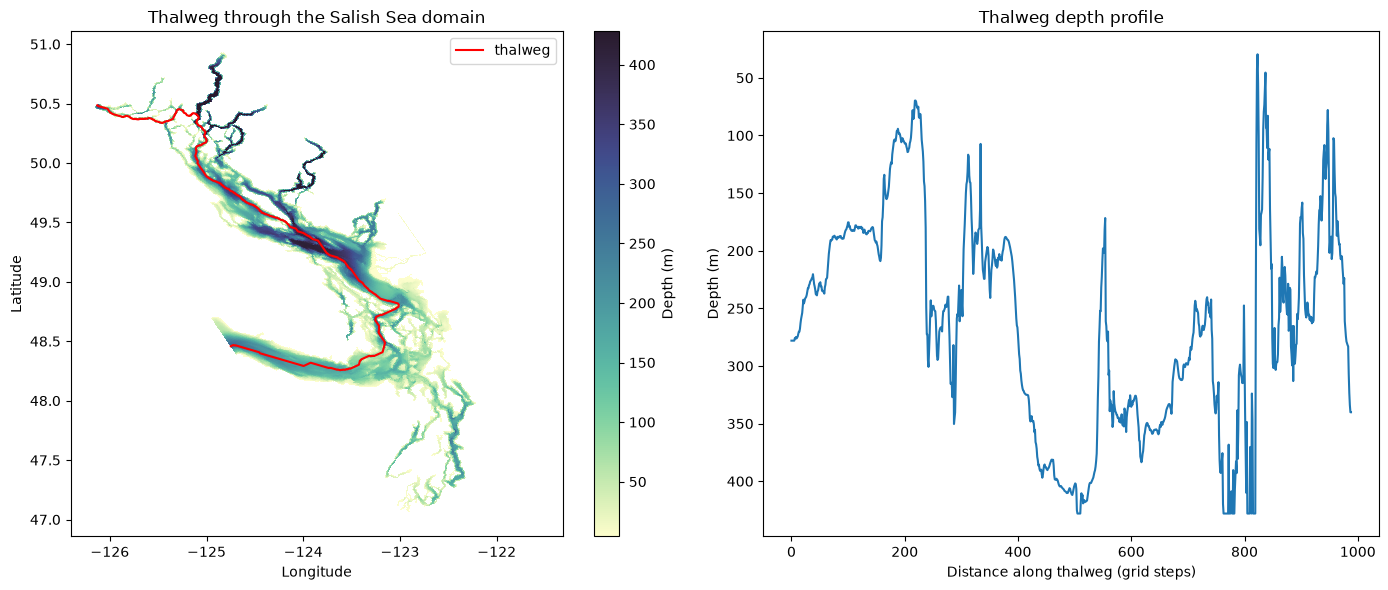

In [13]:
# Find the thalweg: the deepest continuous path through the domain.
#
# The basin curves, so a simple "one point per row" walk breaks down in
# two ways: the thalweg can cross a single gridY row more than once where the
# channel bends, and the domain's real entrances aren't at gridY==0 -- the
# Salish Sea has two open-ocean connections (see background section above):
# the Strait of Juan de Fuca on the west edge (gridX==0) and Johnstone Strait
# / Discovery Passage on the north edge (gridY==897). We want the thalweg
# connecting those two.
#
# To handle the curvature properly we treat every water grid cell as a node
# in a graph, connect each to its 8 neighbours, and use Dijkstra's algorithm
# to find the least-cost path between the two boundary openings -- weighting
# each edge by 1/depth so the cheapest path is the one that stays deepest.
# This lets the path move freely in x and y (including doubling back), unlike
# a per-row walk.

from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import dijkstra

ny, nx = depth.shape
valid = ~np.isnan(depth)

# Map each water cell to a node index (land cells are excluded from the graph entirely)
node_id = np.full(depth.shape, -1, dtype=np.int64)
node_id[valid] = np.arange(valid.sum())
grid_y, grid_x = np.nonzero(valid)
cost = 1.0 / depth[valid]  # deeper cells are "cheaper" to pass through

# Build edges to each of the 8 neighbouring cells
shifts = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]
edge_src, edge_dst, edge_weight = [], [], []
for dy, dx in shifts:
    y2, x2 = grid_y + dy, grid_x + dx
    in_bounds = (y2 >= 0) & (y2 < ny) & (x2 >= 0) & (x2 < nx)
    y2, x2 = y2[in_bounds], x2[in_bounds]
    is_water = valid[y2, x2]
    src = node_id[grid_y[in_bounds][is_water], grid_x[in_bounds][is_water]]
    dst = node_id[y2[is_water], x2[is_water]]
    step = np.hypot(dy, dx)  # diagonal steps cost sqrt(2) as far as orthogonal ones
    edge_src.append(src)
    edge_dst.append(dst)
    edge_weight.append(step * (cost[src] + cost[dst]) / 2.0)

graph = coo_matrix(
    (np.concatenate(edge_weight), (np.concatenate(edge_src), np.concatenate(edge_dst))),
    shape=(valid.sum(), valid.sum()),
).tocsr()

# Seed and target: the deepest water cell on each of the domain's two open-ocean edges
west_edge_rows = np.nonzero(valid[:, 0])[0]
seed_y, seed_x = west_edge_rows[np.argmax(depth[west_edge_rows, 0])], 0

north_edge_cols = np.nonzero(valid[-1, :])[0]
target_y, target_x = ny - 1, north_edge_cols[np.argmax(depth[-1, north_edge_cols])]

dist, predecessors = dijkstra(
    graph, directed=False, indices=node_id[seed_y, seed_x], return_predecessors=True
)

# Walk the predecessor chain back from the target to the seed to recover the path
path_nodes = [node_id[target_y, target_x]]
while path_nodes[-1] != node_id[seed_y, seed_x]:
    path_nodes.append(predecessors[path_nodes[-1]])
path_nodes = path_nodes[::-1]

thalweg_y = grid_y[path_nodes]
thalweg_x = grid_x[path_nodes]
thalweg_depth = depth[thalweg_y, thalweg_x]
thalweg_lat = latitude[thalweg_y, thalweg_x]
thalweg_lon = longitude[thalweg_y, thalweg_x]

# Plot: map view of the thalweg over bathymetry, and its depth profile
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pcm = axes[0].pcolormesh(longitude, latitude, depth, shading="auto", cmap=cmocean.cm.deep)
axes[0].plot(thalweg_lon, thalweg_lat, color="red", linewidth=1.5, label="thalweg")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Thalweg through the Salish Sea domain")
axes[0].legend()
fig.colorbar(pcm, ax=axes[0], label="Depth (m)")

axes[1].plot(np.arange(len(thalweg_depth)), thalweg_depth)
axes[1].invert_yaxis()  # deeper = down, like a real depth profile
axes[1].set_xlabel("Distance along thalweg (grid steps)")
axes[1].set_ylabel("Depth (m)")
axes[1].set_title("Thalweg depth profile")

plt.tight_layout()
plt.show()

In [14]:
# Create a new data request for data along the thalweg

startTime = (pd.Timestamp.now(tz="UTC") - pd.DateOffset(days=1)).strftime("%Y-%m-%dT%H:%M:%S.000Z")
thalweg_url = build_griddap_url(    
    dataset_id='ubcSSg3DPhysicsFields1hV21-11',  # replace with correct dataset_id from the table above
    variables=['temperature'],                   # replace with variable of interest
    time_range=(startTime, 1, startTime),        # single time stamp
    depth_range=FULL_DEPTH,                      # Full spatial domain
    gridY_range=FULL_GRIDY,               
    gridX_range=FULL_GRIDX,
)
print(thalweg_url)
data = fetch_griddap(thalweg_url)

https://salishsea.eos.ubc.ca/erddap/griddap/ubcSSg3DPhysicsFields1hV21-11.nc?temperature[(2026-08-24T20:31:54.000Z):1:(2026-08-24T20:31:54.000Z)][(0.5000003):1:(441.4661)][(0):1:(897.0)][(0.0):1:(397.0)]


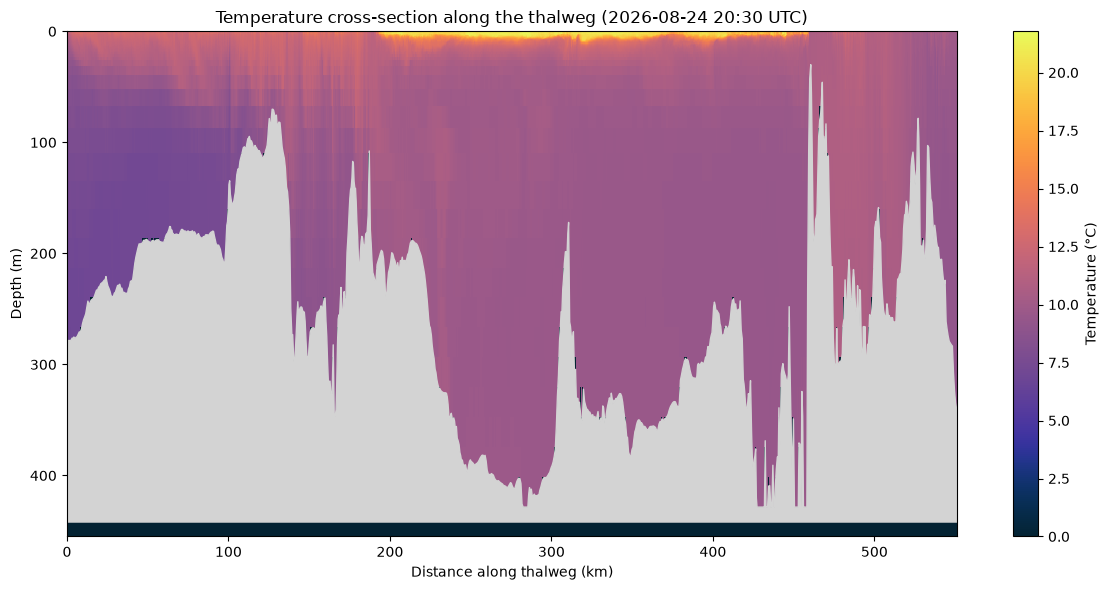

In [15]:
# Create curtain plot: temperature cross-section along the thalweg

cData = data["temperature"].squeeze("time")  # drop the singleton time dim -> (depth, gridY, gridX)

# Pull the temperature value at each (gridY, gridX) point along the thalweg, using
# vectorized isel so gridY/gridX collapse into a single new "thalweg" dimension
# while depth stays a separate axis -> result shape (depth, thalweg)
cData_thalweg = cData.isel(
    gridY=xarray.DataArray(thalweg_y, dims="thalweg"),
    gridX=xarray.DataArray(thalweg_x, dims="thalweg"),
)

# Distance along the thalweg (km), accumulated from thalweg_lat/thalweg_lon (computed
# above) via the haversine formula, so the x-axis is real along-path distance rather
# than a grid-step count
R = 6371.0  # Earth radius, km
lat_rad = np.radians(thalweg_lat)
lon_rad = np.radians(thalweg_lon)
dlat = np.diff(lat_rad)
dlon = np.diff(lon_rad)
a = np.sin(dlat / 2) ** 2 + np.cos(lat_rad[:-1]) * np.cos(lat_rad[1:]) * np.sin(dlon / 2) ** 2
step_km = 2 * R * np.arcsin(np.sqrt(a))
thalweg_distance = np.concatenate(([0], np.cumsum(step_km)))

plt.figure(figsize=(12, 6))

pcm = plt.pcolormesh(
    thalweg_distance,
    data["depth"],
    cData_thalweg,
    shading="auto",
    cmap=cmocean.cm.thermal,
)

# Shade below the seafloor so the plot reads as a cross-section rather than a bare heatmap
plt.fill_between(thalweg_distance, thalweg_depth, data["depth"].max(), color="lightgray", zorder=2)

plt.colorbar(pcm, label="Temperature (°C)")
plt.xlabel("Distance along thalweg (km)")
plt.ylabel("Depth (m)")
timestamp = pd.Timestamp(data["time"].values[0]).strftime("%Y-%m-%d %H:%M")
plt.title(f"Temperature cross-section along the thalweg ({timestamp} UTC)")

# Reverse y-axis so it appears surface - bottom
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Animated surface plots: combining 2D space and time


In [18]:
# Create a new data request for a month of surface data

daysPrior = 30
stride = 24 # grab daily data
startTime = (pd.Timestamp.now(tz="UTC") - pd.DateOffset(days=daysPrior)).strftime("%Y-%m-%dT%H:%M:%S.000Z")
surfMap_url = build_griddap_url(    
    dataset_id='ubcSSg3DPhysicsFields1hV21-11',  # replace with correct dataset_id from the table above
    variables=['temperature'],                   # replace with variable of interest
    time_range=(startTime, stride, 'last'),        # single time stamp
    depth_range=(0.5,1,0.5),                      # just surface data
    gridY_range=FULL_GRIDY,               
    gridX_range=FULL_GRIDX,
)
print(surfMap_url)
data = fetch_griddap(surfMap_url)

https://salishsea.eos.ubc.ca/erddap/griddap/ubcSSg3DPhysicsFields1hV21-11.nc?temperature[(2026-07-26T20:35:17.000Z):24:(last)][(0.5):1:(0.5)][(0):1:(897.0)][(0.0):1:(397.0)]


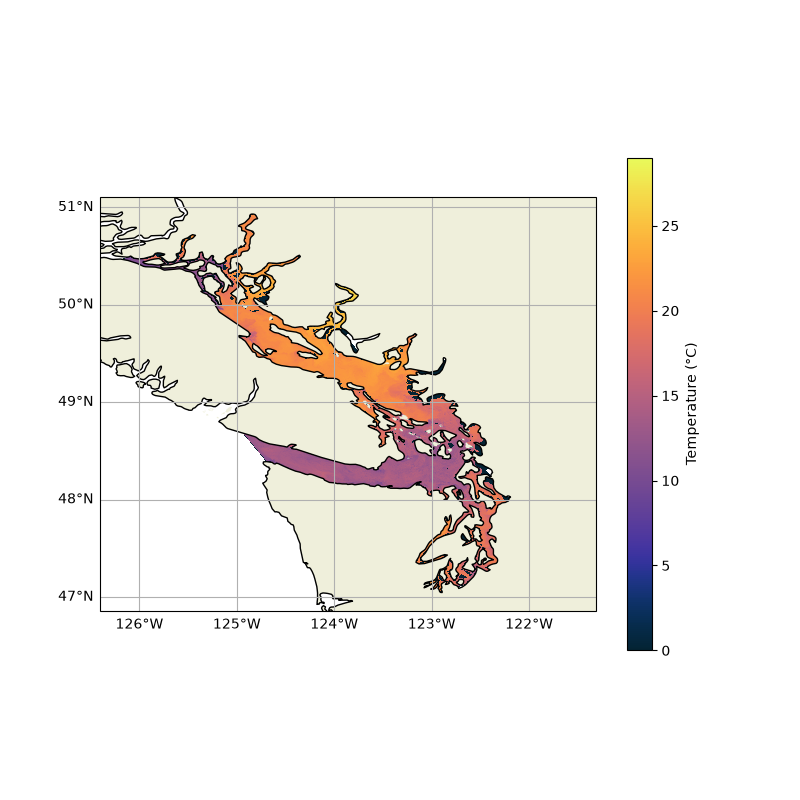

In [19]:
# Create plot: animate the surface field, one frame per day in the time range

cData = data["temperature"].squeeze("depth")  # drop the singleton surface-depth dim -> (time, gridY, gridX)
vmin, vmax = float(cData.min()), float(cData.max())

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Draw the first frame, then just update this mesh's data each iteration below --
# keeps the map, colorbar, and coastlines fixed so only the color updates per frame
pcm = ax.pcolormesh(
    longitude, latitude, cData.isel(time=0).values,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap=cmocean.cm.thermal,
    vmin=vmin, vmax=vmax,
)
fig.colorbar(pcm, ax=ax, label="Temperature (°C)", shrink=0.8)

ax.add_feature(cfeature.LAND, zorder=1)
ax.add_feature(cfeature.COASTLINE, zorder=2)
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
title = ax.set_title("")

# Loop through each day in the time range, redrawing the figure in place with
# clear_output so it plays back like an animation.
#
# We render to a PNG buffer ourselves (bbox_inches=None) rather than calling
# display(fig) directly -- Jupyter's inline backend defaults to bbox_inches="tight"
# for displayed figures, and cartopy's gridlines/feature artists report a bad
# bounding box under that "tight" calculation, which crops the map out of the frame.
for t in cData["time"].values:
    pcm.set_array(cData.sel(time=t).values.ravel())
    title.set_text(f"Surface temperature -- {pd.Timestamp(t).strftime('%Y-%m-%d')}")

    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches=None)
    buf.seek(0)

    clear_output(wait=True)
    display(Image(data=buf.getvalue()))
    time.sleep(0.5)

plt.close(fig)

## Come up with a new kind of plot of your own! 